let's do the second part of the homework with another dataset



In [1]:
!pip install datasets

In [2]:
import os
import zipfile
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import functional as F
from diffusers import UNet2DModel, DDPMScheduler

# --------------------
# Device
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
def show_images(images, nrows=3):
    n = len(images)
    plt.figure(figsize=(nrows*3, nrows*3))
    for i in range(n):
        plt.subplot(nrows, nrows, i+1)
        img_display = None
        if isinstance(images[i], torch.Tensor):
            img_tensor = (images[i] * 0.5 + 0.5).clamp(0, 1)
            img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
        elif isinstance(images[i], Image.Image):
            img_display = np.array(images[i])
        else:
            plt.axis("off")
            continue
        plt.imshow(img_display)
        plt.axis("off")
    plt.show()

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/animal-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animal-faces' dataset.
Path to dataset files: /kaggle/input/animal-faces


In [5]:
cat_folder = "/kaggle/input/animal-faces/train/cat"



In [ ]:
import os

base_path = "/root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1/afhq/train"
print(os.listdir(base_path))


In [7]:
import os
cat_folder = "/root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1/afhq/train/cat"  
print("Number of cat images:", len(os.listdir(cat_folder)))


Number of cat images: 5153


In [8]:
class CatDataset(Dataset):
    def __init__(self, folder):
        self.paths = [os.path.join(folder, f) for f in os.listdir(folder)
                      if f.endswith(".jpg") or f.endswith(".png")]
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

In [9]:
dataset = CatDataset(cat_folder)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)
print(f"Loaded {len(dataset)} cat images.")


Loaded 5153 cat images.


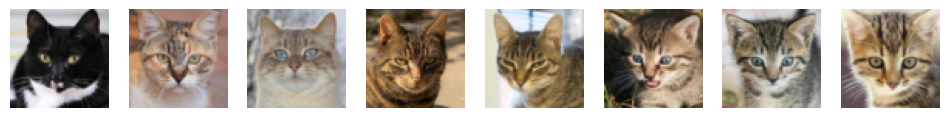

In [10]:
import matplotlib.pyplot as plt

# Get one batch of images
images = next(iter(train_loader))  # CatDataset returns only tensors

# Denormalize images from [-1, 1] back to [0, 1]
images = images * 0.5 + 0.5

# Plot first 8 images
n = min(8, images.size(0))
plt.figure(figsize=(12, 3))
for i in range(n):
    img = images[i].permute(1, 2, 0).cpu().numpy()  # [H, W, C]
    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()


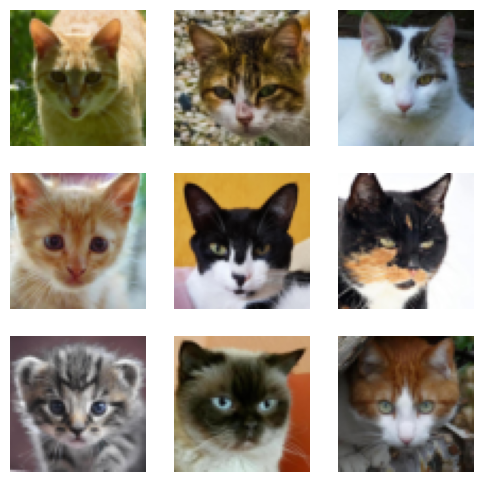

In [11]:
import matplotlib.pyplot as plt

# Get a batch of images
batch_images = next(iter(train_loader))  # [B, 3, 64, 64]

# Take first 9 images
original_images = batch_images[:9]

# Denormalize from [-1,1] to [0,1]
images_to_show = (original_images * 0.5 + 0.5).clamp(0, 1)

# Plot 3x3 grid
plt.figure(figsize=(6, 6))
for i in range(9):
    img = images_to_show[i].permute(1, 2, 0).cpu().numpy()
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.show()


/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


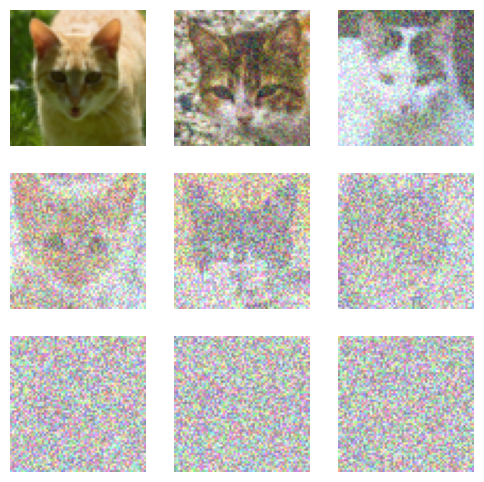

In [12]:
from diffusers import DDPMScheduler
import torch

# Use the SAME 9 images
images = original_images

# Initialize scheduler
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.02)

# Create noise
noise = torch.rand_like(images)

# Choose timesteps
timesteps = torch.linspace(0, scheduler.num_train_timesteps - 1, 9).long()

# Add noise
noised_images = scheduler.add_noise(images, noise, timesteps)

# Denormalize noisy images
noised_to_show = (noised_images * 0.5 + 0.5).clamp(0, 1)

# Plot 3x3 grid
plt.figure(figsize=(6, 6))
for i in range(9):
    img = noised_to_show[i].permute(1, 2, 0).cpu().numpy()
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.show()


In [13]:
from diffusers import UNet2DModel
import torch

model = UNet2DModel(
    in_channels=3,
    sample_size=64,
    block_out_channels=(64, 128, 256, 512),  # 🔥 Bigger model = better quality
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(device)


# Define noised_x and timesteps for testing the model's forward pass
# These values are chosen to match the expected input shape for the model.
noised_x = torch.randn(9, 3, 64, 64).to(device) # Example batch of 9 images
timesteps = torch.randint(0, 1000, (9,)).long().to(device) # Example timesteps for each image

# Pass a batch of data through to make sure it works
with torch.inference_mode():
    out = model(noised_x.to(device), timestep=timesteps.to(device)).sample

print(noised_x.shape)
print(out.shape)

torch.Size([9, 3, 64, 64])
torch.Size([9, 3, 64, 64])


In [14]:
from diffusers import DDPMScheduler

# Initialize scheduler (must match your training setup)
scheduler = DDPMScheduler(
    num_train_timesteps=1000,  # total diffusion steps
    beta_start=0.001,          # starting noise schedule
    beta_end=0.02              # ending noise schedule
)


In [15]:
import torch
import torch.nn.functional as F

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
num_epochs = 50

for epoch in range(num_epochs):
    running_loss = 0.0
    for batch in train_loader:
        # Move batch to device
        clean_images = batch.to(device)

        # Sample noise and timesteps
        noise = torch.randn_like(clean_images).to(device)
        timesteps = torch.randint(0, scheduler.num_train_timesteps, (clean_images.shape[0],), device=device).long()

        # Add noise
        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        # Predict noise
        noise_pred = model(noisy_images, timestep=timesteps).sample

        # Compute loss
        loss = F.mse_loss(noise_pred, noise)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} — Avg Loss: {avg_loss:.6f}")


Epoch 1/50 — Avg Loss: 0.091647
Epoch 2/50 — Avg Loss: 0.030370
Epoch 3/50 — Avg Loss: 0.024250
Epoch 4/50 — Avg Loss: 0.023140
Epoch 5/50 — Avg Loss: 0.021212
Epoch 6/50 — Avg Loss: 0.020363
Epoch 7/50 — Avg Loss: 0.019945
Epoch 8/50 — Avg Loss: 0.019425
Epoch 9/50 — Avg Loss: 0.019229
Epoch 10/50 — Avg Loss: 0.018333
Epoch 11/50 — Avg Loss: 0.019393
Epoch 12/50 — Avg Loss: 0.017424
Epoch 13/50 — Avg Loss: 0.018763
Epoch 14/50 — Avg Loss: 0.016436
Epoch 15/50 — Avg Loss: 0.017313
Epoch 16/50 — Avg Loss: 0.017450
Epoch 17/50 — Avg Loss: 0.016809
Epoch 18/50 — Avg Loss: 0.016538
Epoch 19/50 — Avg Loss: 0.017334
Epoch 20/50 — Avg Loss: 0.017180
Epoch 21/50 — Avg Loss: 0.017501
Epoch 22/50 — Avg Loss: 0.017769
Epoch 23/50 — Avg Loss: 0.016049
Epoch 24/50 — Avg Loss: 0.016439
Epoch 25/50 — Avg Loss: 0.016851
Epoch 26/50 — Avg Loss: 0.017081
Epoch 27/50 — Avg Loss: 0.015768
Epoch 28/50 — Avg Loss: 0.016391
Epoch 29/50 — Avg Loss: 0.015960
Epoch 30/50 — Avg Loss: 0.016268
Epoch 31/50 — Avg L

In [3]:
from diffusers import DDPMPipeline
import torch
import matplotlib.pyplot as plt

# Build pipeline from trained model + scheduler
pipeline = DDPMPipeline(unet=model, scheduler=scheduler)

# Generate 9 images
ims = pipeline(batch_size=9).images   # list of PIL images

# Plot 3x3 grid
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(ims[i])
    plt.axis("off")

plt.show()


NameError: name 'model' is not defined

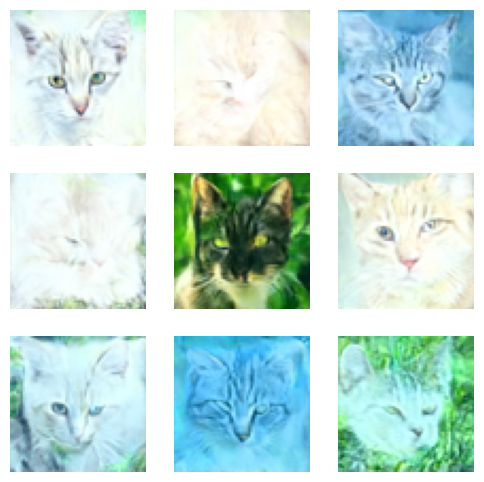

In [18]:
import torch
import matplotlib.pyplot as plt

# Random starting point (9 random images for 3×3 grid)
sample = torch.randn(9, 3, 64, 64).to(device)

# DDPM sampling loop
for t in scheduler.timesteps:
    with torch.inference_mode():
        noise_pred = model(sample, t)["sample"]
    sample = scheduler.step(noise_pred, t, sample).prev_sample

# Convert from [-1,1] → [0,1]
sample = (sample * 0.5 + 0.5).clamp(0, 1)

# Show in 3×3 grid
plt.figure(figsize=(6, 6))
for i in range(9):
    img = sample[i].permute(1, 2, 0).detach().cpu().numpy()
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()
